In [19]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from typing import Callable, Optional
import sys
import os
import tqdm

# This (hopefully) sets the root directory for anyone using the repo
cwd = os.getcwd()  # poison-perf/strategic/
root = os.path.dirname(cwd)  # poison-perf/
sys.path.append(root)

from utils.algorithms import RGD, RGD_audit, PerfGD
from utils.experiment_setup import setup_strategic_classification
from data_prep import load_data

## Strategic Classification: RGD and PerfGD (no poisoning)

In [20]:
# Load strategic credit dataset
data_dir = "data/GiveMeSomeCredit"
data_file = "cs-training.csv"
data_path = os.path.join(root, data_dir, data_file)
X_np, Y_np, data = load_data(data_path)

n_samples, d_plus_bias = X_np.shape
print("n_samples =", n_samples, ", d+1 (with bias) =", d_plus_bias)

# Strategic features (same as Perdomo 2020 credit-simulator)
strat_features = np.array([1, 6, 8]) - 1  # for later indexing

print("Strategic features:\n")
for i, feature in enumerate(strat_features):
    print(i, data.columns[feature + 1])

# Torch copies
device = torch.device("cpu")
X_full = torch.from_numpy(X_np).float().to(device)
Y_full = torch.from_numpy(Y_np).float().to(device)

# Regularization and strategic response strength (epsilon)
lam = 1.0 / n_samples
alpha_strat = 1.0  # strength of strategic response (convergence should break after a certain value)

n_samples = 18357 , d+1 (with bias) = 11
Strategic features:

0 RevolvingUtilizationOfUnsecuredLines
1 NumberOfOpenCreditLinesAndLoans
2 NumberRealEstateLoansOrLines


## RGD (no poisoning) on strategic classification

In [21]:
# RGD hyperparameters
n = n_samples  # Perdomo (2020) uses all samples for each iteration
# n = 1000
max_iter = 50

# Learning rate matching Perdomo's RGD step: eta = 2 / (smoothness + 2*lam)
# Smoothness of logistic loss = (1/(4n)) * sum_i ||x_i||^2 (see strategic/optimization.py)
smoothness = (X_full ** 2).sum().item() / (4.0 * n_samples)
eta = 2.0 / (smoothness + 2.0 * lam)
print("smoothness =", smoothness, ", eta =", eta)

proj_theta = lambda t: t  # no projection
# proj_theta = lambda theta: torch.clamp(theta, min=-1.0, max=1.0)  # Find meaningful projection if thetas go crazy

mu_f, sigma, D_theta, loss, theta_0, grad2_est, f_hat = setup_strategic_classification(
    X_base=X_full,
    Y_base=Y_full,
    strat_features=strat_features.tolist(),
    alpha=alpha_strat,
    lam=lam,
    perfGD=True,
)

# Run RGD
theta_rgd, all_theta_rgd, all_losses_rgd = RGD(
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0,
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    return_losses=True,
)

print("Final theta (RGD):", theta_rgd.detach().cpu().numpy())

smoothness = 4.666283638394073 , eta = 0.42859660047914183
Final theta (RGD): [-0.00832391 -0.29596972  1.7564741  -0.03907065 -0.4112674   0.13016513
  1.4900061   0.2383353   0.2299233   0.08712994 -0.41823286]


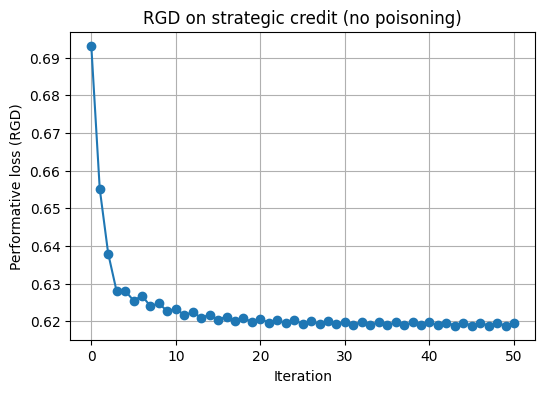

In [22]:
# Plot RGD performative loss trajectory (evaluated on true induced distribution)

plt.figure(figsize=(6, 4))
plt.plot(all_losses_rgd, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Performative loss (RGD)")
plt.title("RGD on strategic credit (no poisoning)")
plt.grid(True)
plt.show()

## PerfGD (no poisoning) on strategic classification

In [23]:
# Run PerfGD with simple f_hat and zero performative correction

theta_perfgd, all_theta_perfgd, all_losses_perfgd = PerfGD(
    f_hat=f_hat,
    grad2_est=grad2_est,
    D_theta=D_theta,
    loss=loss,
    theta_0=theta_0,
    n=n,
    eta=eta,
    max_iter=max_iter,
    proj_theta=proj_theta,
    return_losses=True,
)

print("Final theta (PerfGD):", theta_perfgd.detach().cpu().numpy())

Final theta (PerfGD): [-0.05066353 -0.3944387   1.8129901  -0.05032106 -0.40135655 -0.32388598
  1.36266     0.0556595   0.24596326  0.09024996 -0.24111792]


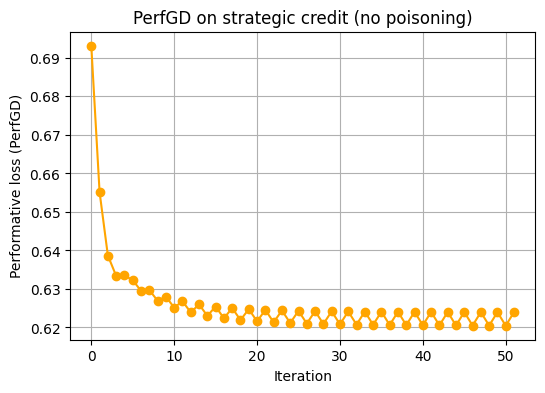

In [24]:
# Plot PerfGD performative loss trajectory

plt.figure(figsize=(6, 4))
plt.plot(all_losses_perfgd, marker="o", color="orange")
plt.xlabel("Iteration")
plt.ylabel("Performative loss (PerfGD)")
plt.title("PerfGD on strategic credit (no poisoning)")
plt.grid(True)
plt.show()